# Model

In [1]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name,
)

In [2]:
subs = ["A", "B", "C"]
for sub_label in subs:
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    parser["onsite_energy"][sub_label]["E_s"] = -5
    for nn_label in subs:
        try:
            parser["nn_hopping"][nn_label]["t_ss_sigma"] = -1
        except:
            pass
        try:
            parser["kane_mele_soc"][nn_label]["lambda_ss"] = -0.1
        except:
            pass
    print(parser)

{'onsite_energy': {'A': {'E_s': -5, 'E_p': 0}}, 'nn_hopping': {'B': {'t_ss_sigma': -1, 't_sp_sigma': 0, 't_pp_sigma': 0, 't_pp_pi': 0, 'delta_heavy': 0, 'delta_light': 0}, 'C': {'t_ss_sigma': -1, 't_sp_sigma': 0, 't_pp_sigma': 0, 't_pp_pi': 0, 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'A': {'lambda_ss': -0.1, 'lambda_sp': 0, 'lambda_pp': 0}, 'B': {'lambda_ss': -0.1, 'lambda_sp': 0, 'lambda_pp': 0}, 'C': {'lambda_ss': -0.1, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'A': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': 0}}, 'interaction': {'A': {'U_s': 0, 'U_p': 0, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': 0, 'n_px_down': 0, 'n_py_up': 0, 'n_py_down': 0, 'n_pz_up': 0, 'n_pz_down': 0}}}
{'onsite_energy': {'B': {'E_s': -5, 'E_p': 0}}, 'nn_hopping': {'A': {'t_ss_sigma': -1, 't_sp_sigma': 0, 't_pp_sigma': 0, 't_pp_pi': 0}, 'C': {'t_ss_sigma': -1, 't_sp_sigma': 0, 't_pp_sigma': 0, 't_pp_pi': 0}}, 'kane_mele_soc': {'A': {'lambda_ss': -0.1, 'lambda_sp': 0, 'lambda_pp': 0}, 'B': {'lam

In [3]:
location = "edge"
problem.setup(
    N_r = 16, # size of lattice in real space
    N_k = 400, # reciprocal space discretization
    location = location,
    BZ="extended",
    dangling_bonds=True
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [4]:
g = problem.geometry
tb_edge = problem.hamiltonian["edge"]["tight_binding"]

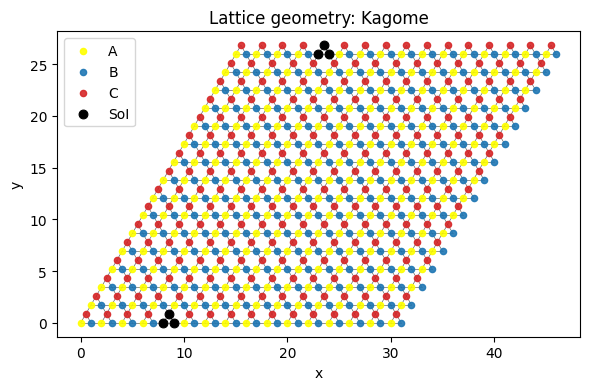

In [5]:
edge_sites = [0, 1, 2, -3, -2, -1]
g.plot_lattice(tb_edge.sublattice_idxs[edge_sites])

In [6]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


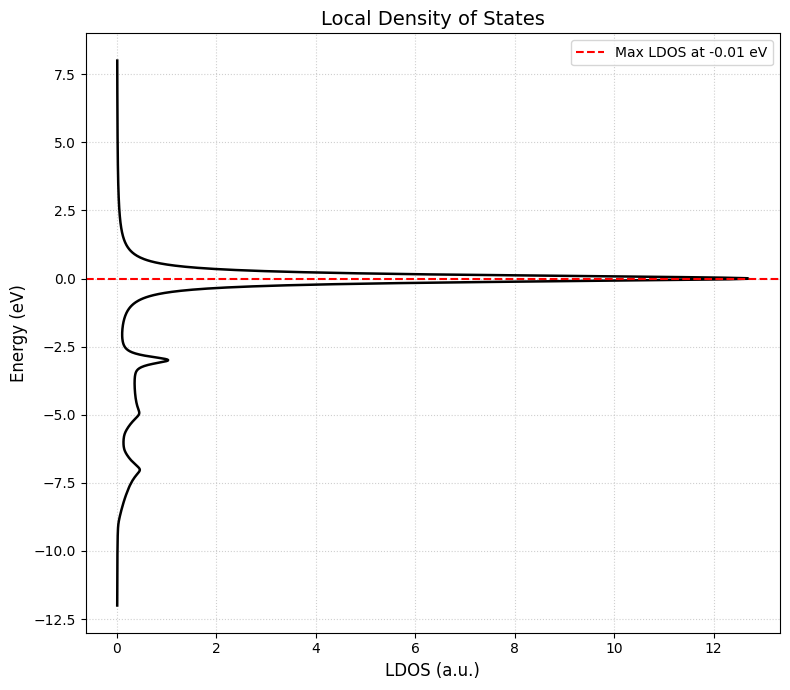

In [7]:
invariants = problem.hamiltonian["edge"]["topological_invariants"]
LDOS, E = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 8, 
    E_min = -12,
    eta = 0.15
)

invariants.plot_density_of_states(LDOS, E)

In [8]:
# DOS, E = invariants.get_density_of_states(
#     E_max = 10, 
#     E_min = -12,
#     eta = 0.15
# )

# invariants.plot_density_of_states(DOS, E)

In [9]:
import numpy as np
k_target = np.pi/2
edge_bands = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=k_target, threshold=0.2)
print(edge_bands)

[np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(62), np.int64(63), np.int64(64), np.int64(65)]


In [10]:
# edge_bands = [320, 316, 327, 348, 349]
edge_bands

[np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65)]

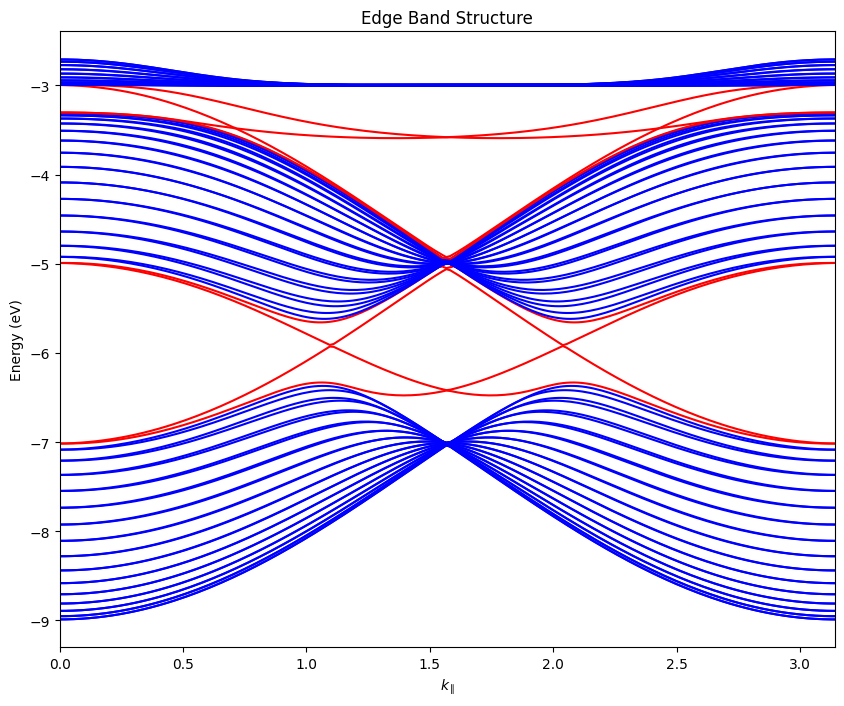

In [11]:
tb_edge.plot_dispersion(g, edge_bands=edge_bands, x_max=np.pi, x_min=0)

Total norm: 1.000000


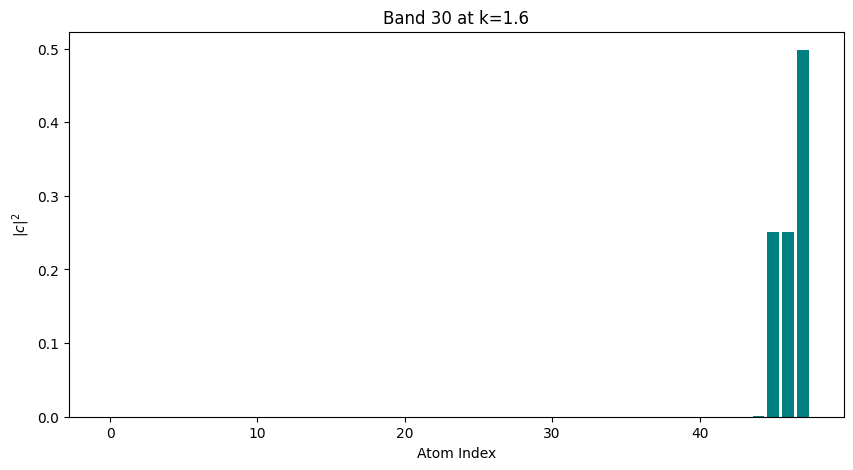

Total norm: 1.000000


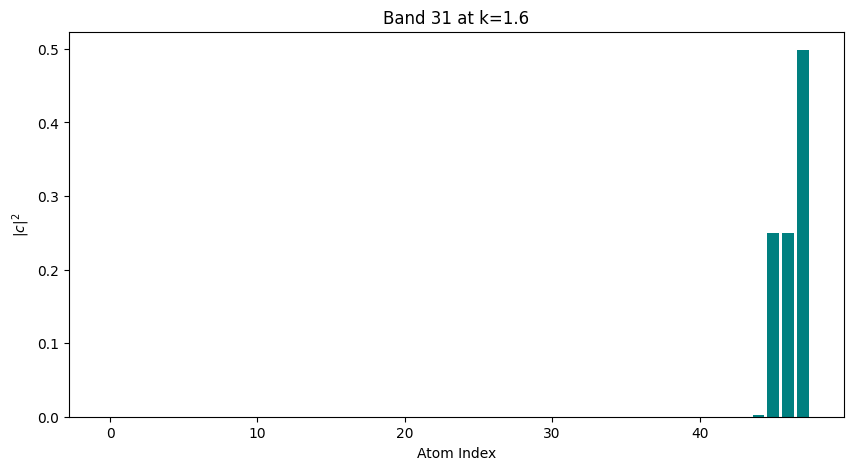

Total norm: 1.000000


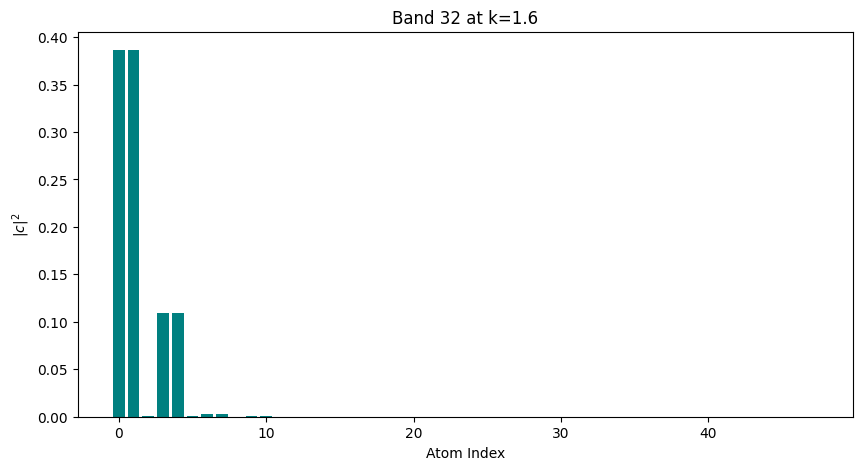

Total norm: 1.000000


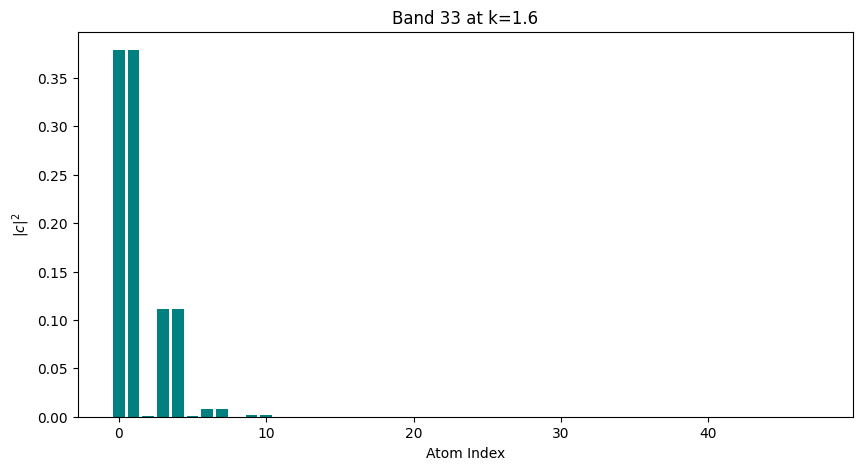

Total norm: 1.000000


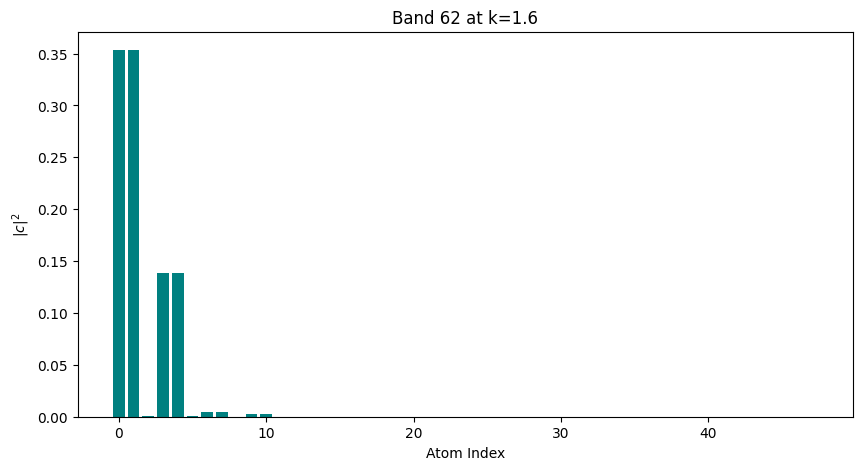

Total norm: 1.000000


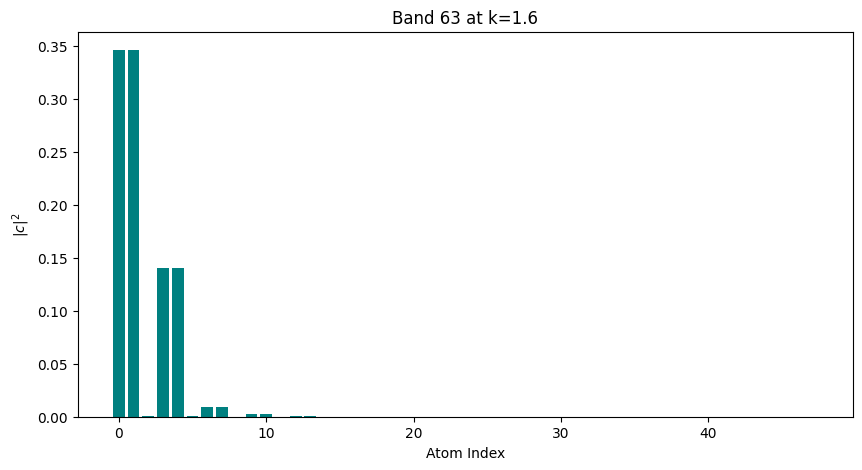

Total norm: 1.000000


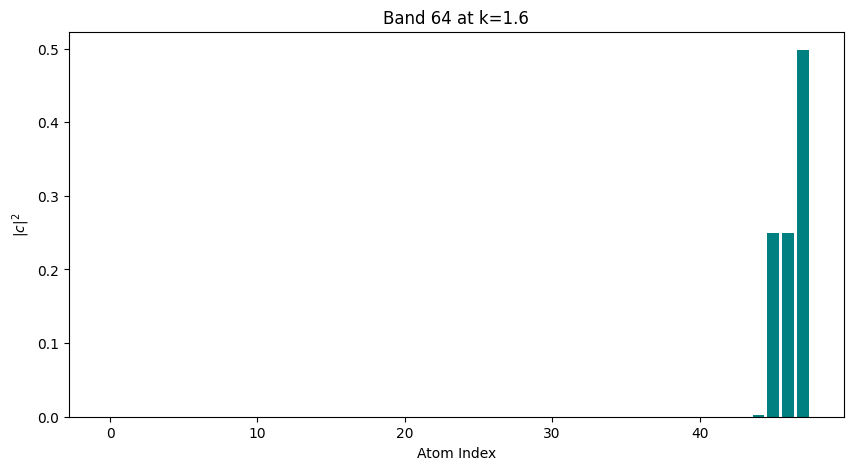

Total norm: 1.000000


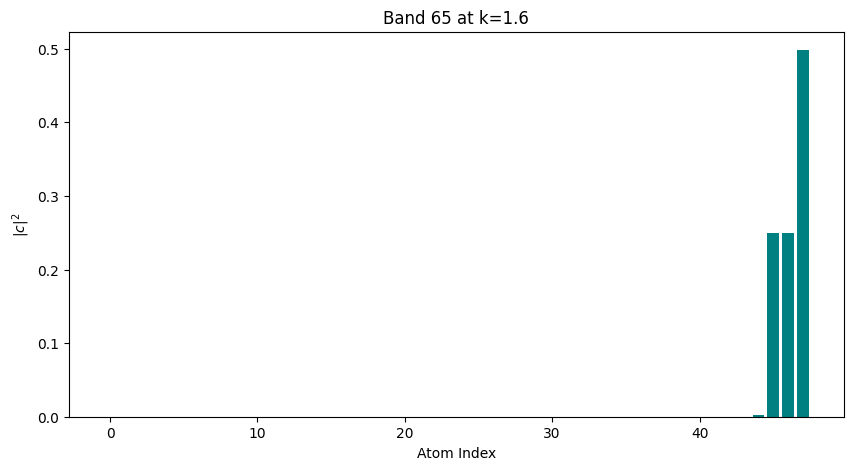

In [12]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"Total norm: {total_norm:.6f}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()